In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import sklearn 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data = pd.read_csv('Datasets/libre.csv')
data.head(5)

,t,y
0,0.684784,7.993583
1,0.574845,6.988172
2,0.940745,10.176502
3,0.724918,7.523874
4,0.018540,4.814125


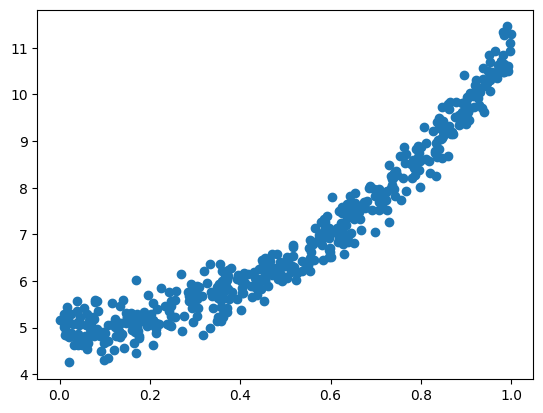

In [3]:
plt.scatter(data['t'],data['y'])
plt.show()

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       500 non-null    float64
 1   y       500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [5]:
x = np.array(data[['t']])
y = np.array(data[['y']])

#no se necesita preprocesar los datos, el método de ajusta a los datos, q pro los arboles de decision, el problema es el sobreajuste
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.5)

In [6]:
regressor = DecisionTreeRegressor()
regressor.fit(x_train,y_train)

DecisionTreeRegressor()

In [7]:
y_pred = regressor.predict(x_test) 
mse = mean_squared_error(y_test,y_pred)
mse

0.18441387917955987

In [8]:
regressor_p = DecisionTreeRegressor(max_depth = 3, 
                                    min_samples_split = 10,
                                    min_samples_leaf = 3)

regressor_p.fit(x_test,y_test)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=3, min_samples_split=10)

In [9]:
y_pred_p = regressor_p.predict(x_test)
mse = mean_squared_error(y_test,y_pred_p)
mse

0.10338545038901573

In [10]:
from sklearn.tree import plot_tree

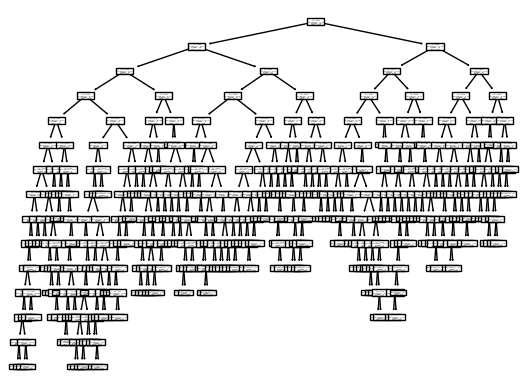

In [11]:
plot = plot_tree(decision_tree = regressor,
                feature_names = ['t'])

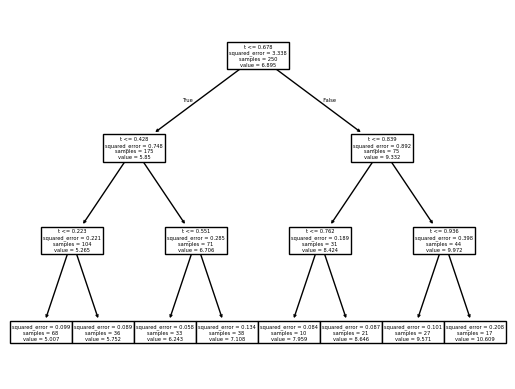

In [12]:
plot = plot_tree(decision_tree = regressor_p,
                feature_names = ['t'])

In [13]:
regressor_a = DecisionTreeRegressor(ccp_alpha = 0.01)
regressor_a.fit(x_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.01)

In [14]:
y_pred_a = regressor_a.predict(x_test)
mse = mean_squared_error(y_test,y_pred_a)
mse

0.14773379703862854

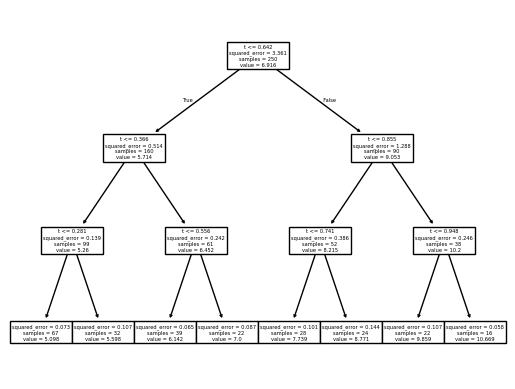

In [15]:
plot = plot_tree(decision_tree = regressor_a,
                feature_names = ['t'])

In [16]:
path = regressor_a.cost_complexity_pruning_path(x_train, y_train)

In [17]:
ccp_alphas = path.ccp_alphas

In [29]:
Alpha = []
MSE = []
for alpha in ccp_alphas:
    reg = DecisionTreeRegressor(ccp_alpha = alpha)
    reg.fit(x_train, y_train)
    mse = mean_squared_error(y_test,reg.predict(x_test))
    #print(f"ccp_alpha = {alpha:.10f}, mse = {mean_squared_error(y_test,reg.predict(x_test)):.10f}")
    Alpha.append(alpha)
    MSE.append(mse)

mse_o = np.argmin(MSE)
print("El valor optimo de alpha es: ", Alpha[mse_o])

El valor optimo de alpha es:  0.00240399526101325


In [31]:
regressor_b = DecisionTreeRegressor(ccp_alpha = 0.00240399526101325)
regressor_b.fit(x_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.00240399526101325)

In [32]:
y_pred_b = regressor_b.predict(x_test)
mse = mean_squared_error(y_test,y_pred_b)
mse

0.11584828849878218